In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch  
import torch.nn as nn  
from torch.utils.data import Dataset, DataLoader  
from model import OccamNet  
from train import train  
  
# 1. 定義 Dataset 類  
class data(Dataset):  
    def __init__(self, inputs, targets, variances):  
        self.x = inputs  
        self.y = targets  
        self.variance = variances  
      
    def __len__(self):  
        return self.x.size()[0]  
      
    def __getitem__(self, idx):  
        return (self.x[idx], self.y[idx], self.variance[idx])  
  
# 2. 準備數據  
dataset_size = 600  
number_of_inputs = 1  
number_of_outputs = 1  
  
# 生成輸入數據 (從 -10 到 10)  
x = torch.empty((dataset_size, number_of_inputs)).uniform_(-10, 10)  
  
# 生成目標數據 (例如: y = sin(x))  
y = 2.5 * torch.sin(3 * x) + 0.5
  
# 設定方差  
variances = torch.full([x.shape[0], 1], torch.std(y).item())  
  
# 3. 創建 DataLoader  
batch_size = 200  
dl = DataLoader(data(x, y, variances), batch_size=batch_size, shuffle=True)  
  
# 4. 創建模型  
model = OccamNet(  
    bases=["SINE", "ADDITION", "SUBTRACTION", "MULTIPLICATION", "SQUARE"],  # , "IDENTITY", "NEGATIVE", "MAX", "MIN"
    constants=["ONE", "TWO"],  
    batch_size=batch_size,  
    depth=3,  
    temperature=1,  
    last_layer_temperature=1,  
    device=torch.device("cpu"),  
    number_of_inputs=number_of_inputs,  
    number_of_outputs=number_of_outputs,  
    recurrence_depth=1, # 要小於 depth
    sampling_size=100,  
    skip_connections=True  
)  
  
# 5. 訓練模型  
loss = model.train(  
    dataset=dl,  
    epochs=4500,  
    learning_rate=0.005,  
    loss_function=nn.MSELoss(),  
    x=x,  
    y=y,  
    truncation_parameter=5,  
    temperature=[1, 1],  
    variances=torch.std(y).item(),  
    skip_connections=True,  
    temperature_evolution="still",  
    training_method="evolutionary"  
)  
  
print("訓練完成!")

do we have skip connections in the OccamNet? True
number of epochs is 4500
訓練完成!s3800 -- Loss 0.3939 -- Equation[2*sin(x_0*(2 + 1))])]]


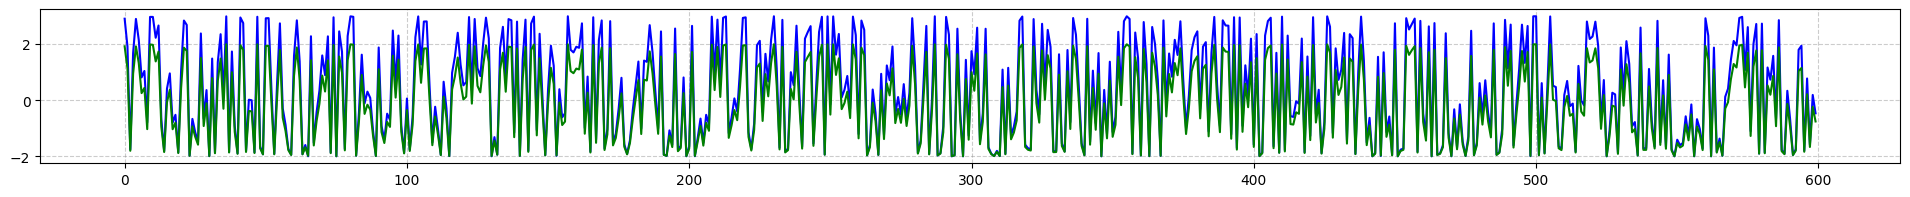

In [4]:
import matplotlib.pyplot as plt
y = y.reshape(-1, )
y_pred = model(x).reshape(-1, )
plt.figure(figsize=(24, 2))
plt.plot(y, color = "blue")
plt.plot(y_pred.detach(), color = "green")
plt.grid(color = "gray", linestyle = "--", alpha = .4)
plt.show()

In [5]:
equation = model.get_model_equation()  
print(equation)

[2*sin(x_0*(2 + 1))]
